# Lung single-cell RNA seq data
Objective:
- We want to verify whether our model can find the cell-cell contact between SMG serous and B Plasma lgA.

In [5]:
import scanpy as sc
import pandas as pd
import scipy.io
import numpy as np
from scipy.sparse import csr_matrix

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Loading the single-cell pulmonary fabrosis samples

Data can be downloaded via the GEO database: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE136831

In [2]:
mtx_path = "/scratch/project_465001820/Spatialformer_main_practice/downstream/cell_cell_communication/data/GSE136831_RawCounts_Sparse.mtx.gz"
meta_path = "/scratch/project_465001820/Spatialformer_main_practice/downstream/cell_cell_communication/data/GSE136831_AllCells.Samples.CellType.MetadataTable.txt.gz"
geneid_path = "/scratch/project_465001820/Spatialformer_main_practice/downstream/cell_cell_communication/data/GSE136831_AllCells.GeneIDs.txt.gz"
# Load the sparse matrix from the .mtx file
mtx_data = scipy.io.mmread(mtx_path).tocsr()
mtx_data = mtx_data.transpose()
# Load metadata (cell annotations)
meta_data = pd.read_csv(meta_path, sep="\t", index_col=0)

# Load gene identifiers
gene_ids = pd.read_csv(geneid_path, sep="\t", header=0)

# Verify the data shapes
print("Matrix shape:", mtx_data.shape)
print("Metadata shape:", meta_data.shape)
print("Gene IDs:", len(gene_ids))

# Create AnnData object
adata = sc.AnnData(X=mtx_data)

# Set the cell metadata
adata.obs = meta_data

# Set the gene identifiers
adata.var = gene_ids

# Display the AnnData object
print(adata)

Matrix shape: (312928, 45947)
Metadata shape: (312928, 8)
Gene IDs: 45947


/tmp/ipykernel_70704/2141424741.py:19: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = sc.AnnData(X=mtx_data)


AnnData object with n_obs × n_vars = 312928 × 45947
    obs: 'nUMI', 'nGene', 'CellType_Category', 'Manuscript_Identity', 'Subclass_Cell_Identity', 'Disease_Identity', 'Subject_Identity', 'Library_Identity'
    var: 'Ensembl_GeneID', 'HGNC_EnsemblAlt_GeneID'


In [3]:
#select the specific cell types in single-cell dataset
adata.obs["Manuscript_Identity"].unique()

array(['ncMonocyte', 'Macrophage_Alveolar', 'NK', 'cMonocyte',
       'Lymphatic', 'Macrophage', 'Fibroblast', 'Basal', 'Myofibroblast',
       'Multiplet', 'cDC2', 'B', 'VE_Venous', 'T', 'ATII', 'ATI',
       'VE_Capillary_A', 'VE_Arterial', 'Ciliated', 'Club',
       'VE_Capillary_B', 'B_Plasma', 'ILC_A', 'T_Cytotoxic', 'Goblet',
       'T_Regulatory', 'Mesothelial', 'ILC_B', 'SMC', 'cDC1',
       'DC_Langerhans', 'Mast', 'pDC', 'DC_Mature', 'VE_Peribronchial',
       'Pericyte', 'Aberrant_Basaloid', 'Ionocyte', 'PNEC'], dtype=object)

Only selecting the overlapping cell types

In [4]:
import numpy as np
def sample_fraction(adata, cell_type_column, frac=0.1):
    df = adata.obs.copy()
    df['sample_index'] = np.arange(len(df))
    sampled_indices = (df.groupby(cell_type_column)
                         .apply(lambda x: x.sample(frac=frac))
                         .reset_index(drop=True)['sample_index'])
    return adata[sampled_indices]

In [5]:
ovlp_ct = ["ATI", "ATII", "Basal", "Ciliated", "NK", "Lymphatic", "Macrophage", "Fibroblast", "B",
          "T", "Mesothelial", "Mast", "pDC", "SMC"]

In [6]:
from scipy.sparse import csr_matrix
#rename the gene columns
adata.var['gene_name'] = adata.var['HGNC_EnsemblAlt_GeneID'].astype(str)

#to csr matrix
adata.X = csr_matrix(adata.X)
#selecting the cell types and getting the certain fraction of cell types
adata_subset = adata[adata.obs["Manuscript_Identity"].isin(ovlp_ct)]

# Sample 10% from each cell type in the filtered AnnData object
adata_subset_10fra = sample_fraction(adata_subset, "Manuscript_Identity", 0.003)

/tmp/ipykernel_30477/3453403415.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac))


In [7]:
adata_subset.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 357777864 stored elements and shape (168705, 45947)>

In [8]:
adata_subset_10fra

View of AnnData object with n_obs × n_vars = 506 × 45947
    obs: 'nUMI', 'nGene', 'CellType_Category', 'Manuscript_Identity', 'Subclass_Cell_Identity', 'Disease_Identity', 'Subject_Identity', 'Library_Identity'
    var: 'Ensembl_GeneID', 'HGNC_EnsemblAlt_GeneID', 'gene_name'

Saving the anndata

In [10]:
selected_cells

Index(['052CO-a_GGGAATGTCGACAGCC', '021I_TGCTGCTCAAGACACG',
       '192CO-a_TCCACACCATTGGTAC', '133C-a_TCAACGAGTTCCTCCA',
       '052CO-a_CCACCTAAGATCTGAA', '193CO-b_CAGCAGCTCCACGTTC',
       '133C-a_AGATCTGTCTTGGGTA', '133C-a_CGCTTCAAGGCGCTCT',
       '207CO_TGTGTTTGTCCAGTGC', '166I-a_GCTTCCACATACTACG',
       ...
       '052CO-a_ACACCGGCAGCATGAG', '052CO-a_AACTCTTTCAGCCTAA',
       '186CO-b_GGTGTTAGTTTGTTGG', '465C_CTAGAGTGTCGACTAT',
       '193CO-b_TCAGGATTCGTTTATC', '056CO_ACAGCCGCAGTCACTA',
       '152CO-a_AACTCTTGTAGCGCAA', '222C_CGGACTGGTCGAGTTT',
       '178CO_CCGTGGATCGCATGGC', '053I_GTCATTTGTCGGCACT'],
      dtype='object', name='CellBarcode_Identity', length=506)

In [50]:

# adata_subset_10fra.var['gene_name'] = adata_subset_10fra.var['gene_name'].astype(str)
adata_subset_10fra.write("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/data/test.h5ad")

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/scratch/proj

loading the anndata

In [6]:
adata_subset_10fra = sc.read("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/data/test.h5ad")

In [5]:
adata_subset_10fra

AnnData object with n_obs × n_vars = 506 × 45947
    obs: 'nUMI', 'nGene', 'CellType_Category', 'Manuscript_Identity', 'Subclass_Cell_Identity', 'Disease_Identity', 'Subject_Identity', 'Library_Identity'
    var: 'Ensembl_GeneID', 'HGNC_EnsemblAlt_GeneID', 'gene_name'

In [8]:
selected_cells = adata_subset_10fra.obs.index

In [6]:
cell_types = np.unique(adata_subset_10fra.obs["Manuscript_Identity"], return_counts=True)[0]

In [7]:
from tqdm import tqdm
import sys
sys.path.append("/scratch/project_465001820/Spatialformer")
import os
import scanpy as sc
import spatialformer as sp
import importlib
importlib.reload(sp)

/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'spatialformer' from '/scratch/project_465001820/Spatialformer/spatialformer/__init__.py'>

In [11]:
%%time

# If you want to reload only the `spatialformer` package
# importlib.reload(sp)
batch_size = 64
tissue = "Lung"
condition = "Disease"
#no 5k panel
# model_ckp_path = "/scratch/project_465001820/Spatialformer_main_practice/output/checkpoints/step=0096000-train_total_loss=-2.9351-val_total_loss=0.0000.ckpt"

# model_ckp_path = "/scratch/project_465001027/Spatialformer/output/checkpoints/step=0100000-train_total_loss=-2.2727-val_total_loss=0.0000.ckpt"
#for new 5k pair model
model_ckp_path = "/scratch/project_465001820/Spatialformer/output/checkpoints/stepstep=0176000-traintrain_total_loss=-2.8414-valval_total_loss=0.0000.ckpt"
method = "cls" #getting the cls token embeddings



CPU times: user 0 ns, sys: 800 μs, total: 800 μs
Wall time: 381 μs


In [12]:
selected_cells

Index(['052CO-a_GGGAATGTCGACAGCC', '021I_TGCTGCTCAAGACACG',
       '192CO-a_TCCACACCATTGGTAC', '133C-a_TCAACGAGTTCCTCCA',
       '052CO-a_CCACCTAAGATCTGAA', '193CO-b_CAGCAGCTCCACGTTC',
       '133C-a_AGATCTGTCTTGGGTA', '133C-a_CGCTTCAAGGCGCTCT',
       '207CO_TGTGTTTGTCCAGTGC', '166I-a_GCTTCCACATACTACG',
       ...
       '052CO-a_ACACCGGCAGCATGAG', '052CO-a_AACTCTTTCAGCCTAA',
       '186CO-b_GGTGTTAGTTTGTTGG', '465C_CTAGAGTGTCGACTAT',
       '193CO-b_TCAGGATTCGTTTATC', '056CO_ACAGCCGCAGTCACTA',
       '152CO-a_AACTCTTGTAGCGCAA', '222C_CGGACTGGTCGAGTTT',
       '178CO_CCGTGGATCGCATGGC', '053I_GTCATTTGTCGGCACT'],
      dtype='object', name='CellBarcode_Identity', length=506)

In [13]:
all_key_cells = []
all_query_cells = []
for i, query in enumerate(selected_cells):
    key_cells = list(selected_cells)
    querys = len(selected_cells)*[query]
    all_key_cells += key_cells
    all_query_cells += querys


In [15]:

_,paired = sp.tl.embed_data(adata = adata_subset_10fra, 
                            tissue = tissue,
                            condition = condition,
                            method = method,
                            model_ckp_path = model_ckp_path, 
                            batch_size = batch_size,
                            mode = "pair",
                            threshold = 0.7,
                            num_workers = 32,
                            gene_median_path = "/scratch/project_465001820/Spatialformer/data/gene_median.pkl",
                            left_cell = all_key_cells[:1000],
                            right_cell = all_query_cells[:1000],
                            resume_before_5k = False,
                            max_len=300
                            )


Spatialformer - INFO - Loading the SpatialFormer model...


[rank: 0] Global seed set to 42


Spatialformer - INFO - Setting the model to evaluation mode...
Spatialformer - INFO - Model mapped to device: cuda
Spatialformer - INFO - Encoding data into batches...


Processing pairs:   0%|          | 0/16 [00:00<?, ?it/s]

running max length: 611


Processing pairs: 100%|██████████| 16/16 [00:21<00:00,  1.37s/it]


In [16]:
# paired_rsl = torch.cat([i.detach().cpu() for i in paired]).numpy()
#Alternatively, load the calculated results directly

paired_rsl = np.load("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/data/paired_rsl.npy")


In [19]:
paired_rsl.shape

(256036, 2)

In [24]:

# pred = np.zeros((len(selected_cells), len(selected_cells), 2))
pred = paired_rsl.reshape((len(selected_cells), len(selected_cells), 2))
np.save("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/data/pred.npy", pred)

In [23]:
pred.shape

(506, 506, 2)

# Visualizing the predicted cell type colocalization

In [1]:
import numpy as np
#loading the single slide predicted results
# pred = np.load("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/pred.npy")
#loading the all lung slides predicted results
pred = np.load("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/data/pred.npy")

In [2]:
pred[0][0:100]

array([[0.55362576, 0.4463743 ],
       [0.9957956 , 0.00420441],
       [0.98933953, 0.01066052],
       [0.8621489 , 0.1378511 ],
       [0.690714  , 0.30928606],
       [0.9184491 , 0.0815509 ],
       [0.9167094 , 0.08329053],
       [0.96539617, 0.03460386],
       [0.758187  , 0.24181306],
       [0.94051695, 0.0594831 ],
       [0.8071819 , 0.1928181 ],
       [0.9948598 , 0.00514017],
       [0.9922464 , 0.00775355],
       [0.9810761 , 0.01892389],
       [0.9960516 , 0.0039484 ],
       [0.99708337, 0.0029166 ],
       [0.99702424, 0.0029758 ],
       [0.997166  , 0.00283397],
       [0.99684554, 0.00315447],
       [0.9970047 , 0.00299526],
       [0.9971475 , 0.00285247],
       [0.9970329 , 0.00296715],
       [0.9972631 , 0.00273688],
       [0.99716944, 0.00283062],
       [0.9969735 , 0.00302651],
       [0.9971156 , 0.00288442],
       [0.9970367 , 0.00296337],
       [0.9971284 , 0.00287154],
       [0.9971929 , 0.00280705],
       [0.99716043, 0.00283954],
       [0.

In [33]:
ovlp_ct = {"ATI", "ATII", "Basal", "Ciliated", "NK", "Lymphatic", "Macrophage", "Fibroblast", "B",
          "T", "Mast", "pDC", "SMC"}
ovlp_ct_dict = {"ATI": "AT1", "ATII": "AT2", "Basal": "Basal", "Ciliated": "Ciliated", "NK": "NK cells", "Lymphatic": "Lymphatic/DCs", "Macrophage": "Macrophages", "Fibroblast": "Fibroblasts", "B": "B cells",
          "T": "T-cells", "Mast": "Mast", "pDC": "pDCs", "SMC": "SMCs"}



In [56]:
#getting the binary predicted results
all_cell_types = list(adata_subset_10fra.obs["Manuscript_Identity"].values)
cell_types = list(np.unique(adata_subset_10fra.obs["Manuscript_Identity"], return_counts=True)[0])
binary_pred = np.zeros((len(cell_types), len(cell_types)))

for i,query in enumerate(selected_cells):
    ct = all_cell_types[i]
    ct_index = cell_types.index(ct)
    top_index =  np.argsort(pred[i][:,1])[-10:]#getting top 10 index
    pred_ct_index = [cell_types.index(all_cell_types[t]) for t in top_index]#getting predicted cell type index
    binary_pred[ct_index, pred_ct_index] += 1 #annotate as 1 when predicted colocalized
    
    
   

In [57]:
cell_types

['ATI',
 'ATII',
 'B',
 'Basal',
 'Ciliated',
 'Fibroblast',
 'Lymphatic',
 'Macrophage',
 'Mast',
 'Mesothelial',
 'NK',
 'SMC',
 'T',
 'pDC']

To dataframe

In [58]:

pair_df = pd.DataFrame(data = binary_pred, index = cell_types, columns = cell_types)

Remove the "Mesothelial" for overlapping with the spatial data

In [66]:
pair_df = pair_df.loc[~pair_df.index.isin(["Mesothelial"]), ~pair_df.columns.isin(["Mesothelial"])]
#customize the order:
ct_order = ["AT1","AT2"	,"Basal","Ciliated","NK cells","Lymphatic/DCs","Macrophages","Fibroblasts", "T-cells","Mast","SMCs"]

In [67]:
#match the cell type annotation
pair_df2 = pair_df.rename(
    index=ovlp_ct_dict,
    columns=ovlp_ct_dict
)
pair_df2 = pair_df2.loc[ct_order, ct_order]



In [64]:
pair_df2

,AT1,AT2,Basal,Ciliated,NK cells,Lymphatic/DCs,Macrophages,Fibroblasts,B cells,T-cells,Mast,pDCs,SMCs
AT1,3.0,3.0,1.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0
AT2,7.0,12.0,0.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0
Basal,1.0,2.0,5.0,1.0,0.0,0.0,3.0,2.0,0.0,2.0,0.0,0.0,0.0
Ciliated,0.0,3.0,3.0,29.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
NK cells,0.0,1.0,0.0,0.0,34.0,0.0,20.0,1.0,0.0,22.0,2.0,2.0,0.0
Lymphatic/DCs,0.0,0.0,0.0,0.0,0.0,6.0,0.0,6.0,0.0,0.0,0.0,0.0,2.0
Macrophages,0.0,1.0,0.0,0.0,9.0,0.0,327.0,3.0,0.0,10.0,0.0,0.0,0.0
Fibroblasts,0.0,0.0,0.0,0.0,0.0,8.0,0.0,8.0,0.0,0.0,0.0,0.0,5.0
B cells,0.0,0.0,0.0,0.0,3.0,3.0,3.0,0.0,24.0,15.0,0.0,14.0,0.0
T-cells,0.0,0.0,0.0,0.0,26.0,0.0,38.0,1.0,6.0,48.0,0.0,2.0,0.0


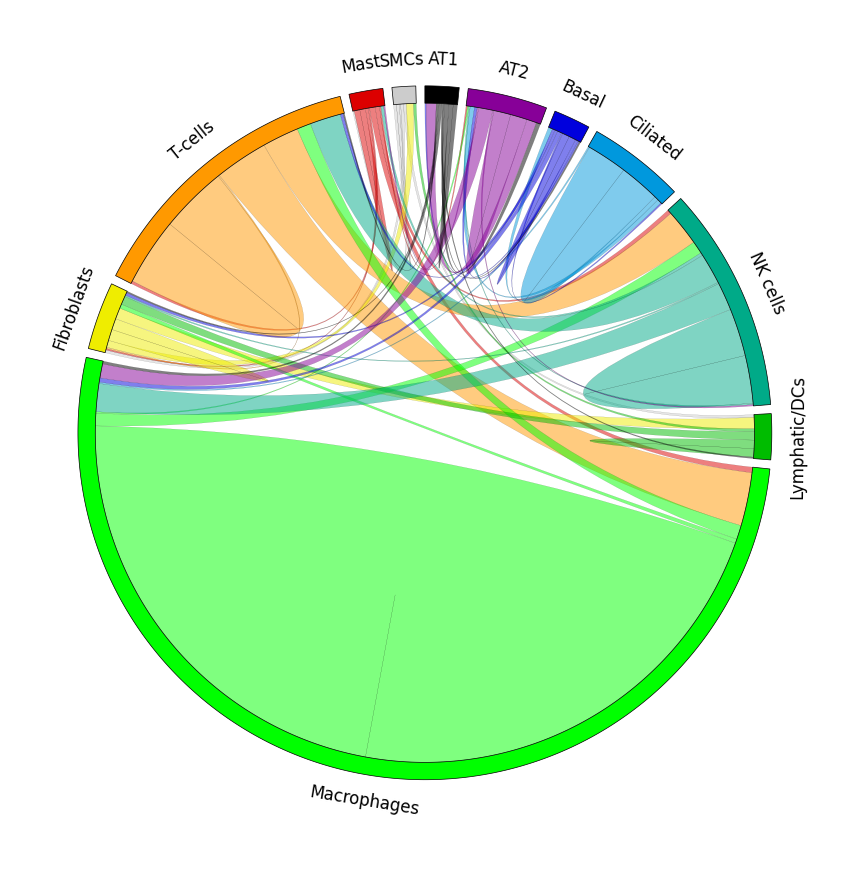

In [68]:
from pycirclize import Circos
import pandas as pd

import matplotlib.pyplot as plt
from pycirclize import Circos  # Replace with the actual library import

# Initialize the Circos plot
circos = Circos.initialize_from_matrix(
    pair_df2,
    space=1.5,
    r_lim=(95, 100),
    cmap="nipy_spectral",
#     ticks_interval=5,
    label_kws=dict(size=12, rotation=60),
    link_kws=dict(ec="black", lw=0.1, direction=0),
)
# dict(r=94, size=12, color="white")
fig = circos.plotfig()

plt.show()

circos.savefig("./figures/pred_ct_colocalization.png", dpi=300)
# circos.savefig("./figures/ct_colocalization.png")

In [42]:
pred[0][:,1][118]

0.9651584625244141

In [37]:
np.argsort(pred[0][:,1])

array([ 74,  73,  79,  76,  78,  77, 330,   7, 271, 337, 263,   4, 485,
       285, 391, 137, 455, 170, 206, 406, 222, 381,  80,  42, 336, 505,
        75, 210, 146,  14, 334, 286, 218, 362, 365, 450, 458, 152, 307,
       312, 408,   5, 417, 138, 358, 102, 401, 215, 432, 117, 324, 339,
       193,  54, 367, 361, 409, 300, 130, 380, 212, 115,  64, 426,  97,
         2, 197, 376, 249, 302, 203,  96, 332, 420,  69, 267, 148, 247,
       175, 375, 169, 308, 453, 407, 124, 287, 139,  92,  11, 145, 166,
       366, 325, 297, 290, 198, 149, 467,   8, 164, 292, 427, 184, 370,
       342, 217, 279, 223,  99, 402, 349, 445, 178, 348, 246,  81, 125,
       141, 135, 171, 311, 368,   9, 269, 140, 372, 106, 276, 174, 127,
       272, 291,  52,  18,  90, 413, 293, 394, 273, 487, 103, 229,  39,
       430, 260, 502,  84, 314, 393, 259, 351, 237,  86, 470, 173, 374,
       168, 389, 353,  61, 245,  24, 119, 313, 363, 304, 497, 262, 473,
       194,  70, 180, 163,  31, 364,  27, 463, 475, 446, 385, 24

In [34]:
pred[0][:,1]


array([9.53854024e-01, 8.94091427e-01, 4.62211251e-01, 9.01179910e-01,
       1.61409929e-01, 3.86417180e-01, 8.46116781e-01, 1.36393934e-01,
       5.65643609e-01, 6.18190587e-01, 8.97996843e-01, 5.27022004e-01,
       7.30260551e-01, 8.00598264e-01, 3.30883980e-01, 9.02581692e-01,
       8.18317294e-01, 8.68841469e-01, 6.42098248e-01, 8.26770902e-01,
       7.57308424e-01, 7.41414189e-01, 8.81487072e-01, 8.31783295e-01,
       6.89213753e-01, 8.40079427e-01, 8.80329967e-01, 7.07826912e-01,
       8.31246734e-01, 8.05613697e-01, 9.11464393e-01, 7.06764162e-01,
       7.60918558e-01, 9.30600524e-01, 7.54353166e-01, 9.45596516e-01,
       8.12454700e-01, 7.69157588e-01, 7.19188333e-01, 6.54089689e-01,
       7.21488059e-01, 8.87094259e-01, 3.00989807e-01, 9.30687249e-01,
       8.73554707e-01, 7.78602719e-01, 8.03497255e-01, 8.66838455e-01,
       7.31935680e-01, 8.40902328e-01, 8.77897561e-01, 8.56550455e-01,
       6.40863001e-01, 8.76185060e-01, 4.31323737e-01, 7.71262586e-01,
      

In [10]:
pred.shape

(506, 506, 2)

In [13]:
np.sum(pred[0][:,0]>pred[0][:,1])

83

In [14]:
np.sum(pred[0][:,0]<pred[0][:,1])

423

In [17]:
pred[0][:,1].min()

0.0006720225792378187

# Visualization of the umap for two cell types

/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))
2025-01-01 16:03:33.873747: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-01 16:03:44.774828: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PA

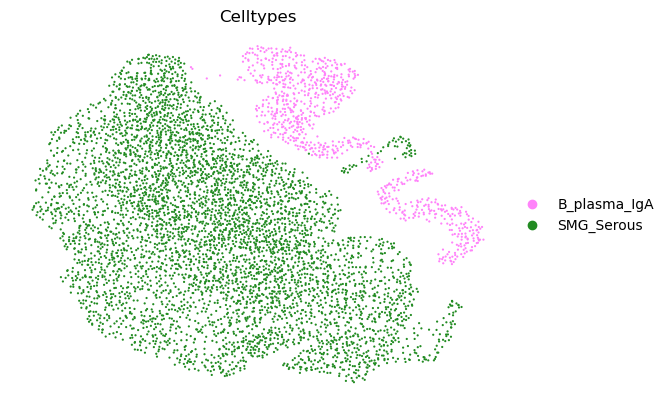

In [54]:
sc.pp.normalize_total(adata_subset, target_sum=1e4)
# sc.pp.log1p(adata_subset)
# Perform PCA to reduce dimensionality
sc.pp.pca(adata_subset, n_comps=10)  # You can adjust the number of components

# Compute nearest neighbors using the PCA representation
sc.pp.neighbors(adata_subset, use_rep='X_pca')


sc.tl.umap(adata_subset, spread =8, min_dist = 5)
sc.pl.umap(adata_subset,color=['Celltypes'], 
                   wspace=0.3, size=10, ncols=1, 
                   frameon=False)

# Generating the SpatialFormer results

In [25]:
import sys
sys.path.append("/scratch/project_465001027/Spatialformer")
sys.path.append("/scratch/project_465001027/Spatialformer/scripts")
from train import manual_train_fm
import scanpy as sc
import spatialformer as sp
import importlib
# If you want to reload only the `spatialformer` package
importlib.reload(sp)

<module 'spatialformer' from '/scratch/project_465001027/Spatialformer/spatialformer/__init__.py'>

In [9]:
adata_subset.obs

,Celltypes,Celltypes_master_high,Celltypes_master_higher,Celltypes_master_higher_immune,Loc_true,Material,Donor,Donor_ID_2,Gender,Sample,...,Version,Study,PoolDon,DonorPool,scDonor_snBatch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
AAACGGGCAACCGCCA-1-WTDAtest7887999-0,B_plasma_IgA,Immune,Immune,B_cell,d_LowLeftPar,cells,A32,411C,M,WTDAtest7887999,...,10x3prime_v2,dissociation,nan,nan,A32_cells,226,226,768.994751,5.476773,0.712199
AAACGGGCAACCGCCA-1-WTDAtest7888002-0,B_plasma_IgA,Immune,Immune,B_cell,a_Trachea,cells,A32,411C,M,WTDAtest7888002,...,10x3prime_v2,dissociation,nan,nan,A32_cells,1612,1612,15639.706055,39.134060,0.250222
CACACCTAGTGTACCT-1-WTDAtest7888002-0,B_plasma_IgA,Immune,Immune,B_cell,a_Trachea,cells,A32,411C,M,WTDAtest7888002,...,10x3prime_v2,dissociation,nan,nan,A32_cells,1360,1360,8899.969727,97.390213,1.094276
TGGACGCAGAAGGACA-1-WTDAtest7888002-0,B_plasma_IgA,Immune,Immune,B_cell,a_Trachea,cells,A32,411C,M,WTDAtest7888002,...,10x3prime_v2,dissociation,nan,nan,A32_cells,912,912,7684.337891,28.812786,0.374955
ACCTTTACACAACTGT-1-HCATisStab7732261-0,B_plasma_IgA,Immune,Immune,B_cell,d_LowLeftPar,cells,A26,386C,F,HCATisStab7732261,...,10x3prime_v2,dissociation,nan,nan,A26_cells,673,673,2663.664307,90.278954,3.389277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCACAGTACGGATG-1-WSSS_A_LNG8757929-1,SMG_Serous,Epithelia,Epithelia,Submucosal_Glands,b_Bronchi.2.3,nuclei,A42,nan,nan,WSSS_A_LNG8757929,...,nan,nan,A42,A42none,A42_nuclei,1211,1211,1877.946289,0.000000,0.000000
TTTCATGTCTAGTGAC-1-WSSS_A_LNG8757929-1,SMG_Serous,Epithelia,Epithelia,Submucosal_Glands,b_Bronchi.2.3,nuclei,A42,nan,nan,WSSS_A_LNG8757929,...,nan,nan,A42,A42none,A42_nuclei,3140,3140,8934.666992,0.000000,0.000000
TTTCCTCCAAATAGCA-1-WSSS_A_LNG8757929-1,SMG_Serous,Epithelia,Epithelia,Submucosal_Glands,b_Bronchi.2.3,nuclei,A42,nan,nan,WSSS_A_LNG8757929,...,nan,nan,A42,A42none,A42_nuclei,2999,2999,8775.594727,0.000000,0.000000
TTTGATCTCAAAGAAC-1-WSSS_A_LNG8757929-1,SMG_Serous,Epithelia,Epithelia,Submucosal_Glands,b_Bronchi.2.3,nuclei,A42,nan,nan,WSSS_A_LNG8757929,...,nan,nan,A42,A42none,A42_nuclei,1411,1411,2388.664551,0.000000,0.000000


In [127]:
adata_subset.var["gene_name"] = adata_subset.var["gene_ids-0"]

/tmp/ipykernel_210179/2113051746.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_subset.var["gene_name"] = adata_subset.var["gene_ids-0"]


In [128]:
from scipy.sparse import csr_matrix

adata_subset.X = csr_matrix(adata_subset.X)


In [129]:
adata_subset.obs["Celltypes"].unique()

['B_plasma_IgA', 'B_naive', 'SMG_Serous', 'Fibro_perichondrial', 'Myoepithelial']
Categories (5, object): ['B_naive', 'B_plasma_IgA', 'Fibro_perichondrial', 'Myoepithelial', 'SMG_Serous']

In [130]:
SMG_index = np.array(adata_subset[adata_subset.obs["Celltypes"] == "SMG_Serous"].obs.index)

In [131]:
Myo_index = np.array(adata_subset[adata_subset.obs["Celltypes"] == "Myoepithelial"].obs.index)

In [132]:
IgA_index = np.array(adata_subset[adata_subset.obs["Celltypes"] == "B_plasma_IgA"].obs.index)

In [133]:
Fib_index = np.array(adata_subset[adata_subset.obs["Celltypes"] == "Fibro_perichondrial"].obs.index)

In [134]:
import numpy as np
querys = np.random.choice(SMG_index, 10)
paired = np.random.choice(IgA_index, 10)
nonpaired1 = np.random.choice(Myo_index, 10)
nonpaired2 = np.random.choice(Fib_index, 10)

In [139]:
%%time
batch_size = 16
tissue = "Lung"
condition = "Disease"
# model_ckp_path = "/scratch/project_465001027/Spatialformer/output/checkpoints/step=0096000-train_total_loss=-2.9351-val_total_loss=0.0000.ckpt"
model_ckp_path = "/scratch/project_465001027/Spatialformer/output/checkpoints/step=0100000-train_total_loss=-2.2727-val_total_loss=0.0000.ckpt"
method = "cls" #getting the cls token embeddings
left_cell = ["TGCGCAGTCAGCATGT-1-WTDAtest7732266-0", "TGCGCAGTCAGCATGT-1-WTDAtest7732266-0"]
right_cell = ["CTAGGTATCTGAGTCA-1-HCA_A_LNG9387709-1", "ACCTTTACACAACTGT-1-HCATisStab7732261-0"]
embed_adata = sp.tl.embed_data(adata_subset, 
                              tissue,
                              condition,
                               method,
                            model_ckp_path, 
                            batch_size,
                            mode = "pair",
                            threshold = 0.7,
                            num_workers = 8,
                            left_cell = querys,
                            right_cell = nonpaired1
                           )



Spatialformer - INFO - Loading the SpatialFormer model...


[rank: 0] Global seed set to 42


require grad: True
Spatialformer - INFO - Setting the model to the evaluation mode...
Spatialformer - INFO - The model is mapped into cpu
Spatialformer - INFO - Encoding the data into the batch...


1it [00:04,  4.36s/it]

CPU times: user 5min 19s, sys: 1min 4s, total: 6min 24s
Wall time: 5.58 s


In [140]:
embed_adata[1]


[array([[0.67687786, 0.3231222 ],
        [0.1053376 , 0.89466244],
        [0.27369574, 0.7263043 ],
        [0.21698321, 0.7830168 ],
        [0.47570375, 0.5242963 ],
        [0.23972856, 0.7602714 ],
        [0.04522088, 0.9547791 ],
        [0.06388779, 0.93611217],
        [0.0455498 , 0.95445013],
        [0.32241958, 0.6775805 ]], dtype=float32)]

In [83]:
embed_adata[1]


[array([[0.01087793, 0.9891221 ],
        [0.00730892, 0.9926911 ],
        [0.01357403, 0.986426  ],
        [0.01017198, 0.989828  ],
        [0.00588342, 0.99411654],
        [0.00890717, 0.99109286],
        [0.02120329, 0.9787967 ],
        [0.00570099, 0.99429893],
        [0.01887678, 0.98112315],
        [0.00914746, 0.99085253]], dtype=float32)]

In [8]:
embed_adata[0][0].shape

(512,)

In [62]:
adata_subset.var

,mt,gene_ids-0,n_cells-0,n_cells_by_counts-0,mean_counts-0,pct_dropout_by_counts-0,total_counts-0,gene_ids-1,n_cells-1,n_cells_by_counts-1,...,n_cells,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,mean,std,gene_name
HES4,False,HES4,16580,16580,0.302786,88.689619,44385.750000,ENSG00000188290,5369,5369,...,18879,True,0.348015,2.407703,0.858933,2,True,-4.553251e-11,0.512652,HES4
TNFRSF18,False,TNFRSF18,5391,5391,0.055908,96.322421,8195.559570,ENSG00000186891,570,570,...,5383,True,0.090583,2.411408,0.957952,2,True,-2.240157e-11,0.252654,TNFRSF18
TNFRSF4,False,TNFRSF4,5113,5113,0.054750,96.512064,8025.812988,ENSG00000186827,521,521,...,5170,True,0.103728,2.507761,1.110371,2,True,1.818045e-11,0.274860,TNFRSF4
AL645728.1,False,AL645728.1,1166,1166,0.008344,99.204590,1223.174438,ENSG00000215014,367,367,...,1251,True,0.020191,2.200457,0.519287,2,True,-9.707694e-12,0.115668,AL645728.1
TTC34,False,TTC34,707,707,0.005823,99.517706,853.601624,ENSG00000215912,2557,2557,...,1571,True,0.040115,2.175078,0.452723,2,True,-1.262883e-11,0.133543,TTC34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UBASH3A,False,UBASH3A,2057,2057,0.015399,98.596776,2257.323975,ENSG00000160185,1330,1330,...,2619,True,0.076424,2.345723,0.911611,2,True,2.340285e-12,0.203516,UBASH3A
RSPH1,False,RSPH1,3765,3765,0.404490,97.431629,59294.632812,ENSG00000160188,3671,3671,...,5024,True,0.237395,2.757026,1.647012,2,True,-2.383287e-11,0.381427,RSPH1
COL18A1,False,COL18A1,13232,13232,0.149136,90.973525,21861.937500,ENSG00000182871,6512,6512,...,16562,True,0.321884,2.337140,0.801880,2,True,9.382796e-12,0.458006,COL18A1
COL6A1,False,COL6A1,14127,14127,0.513421,90.362983,75262.882812,ENSG00000142156,10117,10117,...,19712,True,0.514242,2.488781,0.826094,2,True,-8.717349e-12,0.586709,COL6A1
